In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)

In [3]:
df = pd.read_csv("../data/application_train.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (307511, 122)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...          

In [5]:
print(df["TARGET"].value_counts(dropna=False))
print(df["TARGET"].value_counts(normalize=True, dropna=False))

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [11]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio": df.isnull().mean()
}).sort_values("missing_ratio", ascending=False)
print(missing_summary.head(20))

                          missing_count  missing_ratio
COMMONAREA_MEDI                  214865       0.698723
COMMONAREA_AVG                   214865       0.698723
COMMONAREA_MODE                  214865       0.698723
NONLIVINGAPARTMENTS_MODE         213514       0.694330
NONLIVINGAPARTMENTS_AVG          213514       0.694330
NONLIVINGAPARTMENTS_MEDI         213514       0.694330
FONDKAPREMONT_MODE               210295       0.683862
LIVINGAPARTMENTS_MODE            210199       0.683550
LIVINGAPARTMENTS_AVG             210199       0.683550
LIVINGAPARTMENTS_MEDI            210199       0.683550
FLOORSMIN_AVG                    208642       0.678486
FLOORSMIN_MODE                   208642       0.678486
FLOORSMIN_MEDI                   208642       0.678486
YEARS_BUILD_MEDI                 204488       0.664978
YEARS_BUILD_MODE                 204488       0.664978
YEARS_BUILD_AVG                  204488       0.664978
OWN_CAR_AGE                      202929       0.659908
LANDAREA_M

In [13]:
# DAYS_EMPLOYED = 365243 is a known placeholder value, replace it with NaN
if "DAYS_EMPLOYED" in df.columns:
    anomaly_count = (df["DAYS_EMPLOYED"] == 365243).sum()
    print("DAYS_EMPLOYED anomaly count:", anomaly_count)
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

DAYS_EMPLOYED anomaly count: 55374


In [15]:
categorical_features = df.select_dtypes(exclude=["number"]).columns.tolist()
categorical_features = [col for col in categorical_features if col != "TARGET"]

print("Number of categorical features:", len(categorical_features))
print("Sample categorical features:", categorical_features[:10])

#  use one-hot encoding later in the preprocessing pipeline.
# do NOT fit the encoder on the full dataset here to avoid data leakage.

Number of categorical features: 16
Sample categorical features: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


In [17]:

# Optionally construct new features

# More interpretable age / employment features
if "DAYS_BIRTH" in df.columns:
    df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

if "DAYS_EMPLOYED" in df.columns:
    df["EMPLOYED_YEARS"] = -df["DAYS_EMPLOYED"] / 365

# Ratio features
if {"AMT_INCOME_TOTAL", "AMT_CREDIT"}.issubset(df.columns):
    df["INCOME_CREDIT_RATIO"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"]

if {"CNT_CHILDREN", "CNT_FAM_MEMBERS"}.issubset(df.columns):
    df["CHILDREN_RATIO"] = df["CNT_CHILDREN"] / df["CNT_FAM_MEMBERS"]

if {"AMT_ANNUITY", "AMT_INCOME_TOTAL"}.issubset(df.columns):
    df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

# Aggregate external score features
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
available_ext_cols = [col for col in ext_cols if col in df.columns]

if len(available_ext_cols) > 0:
    df["EXT_SOURCE_MEAN"] = df[available_ext_cols].mean(axis=1)

constructed_features = [
    col for col in [
        "AGE_YEARS",
        "EMPLOYED_YEARS",
        "INCOME_CREDIT_RATIO",
        "CHILDREN_RATIO",
        "ANNUITY_INCOME_RATIO",
        "EXT_SOURCE_MEAN"
    ] if col in df.columns
]

print("Constructed features:", constructed_features)
print(df[constructed_features].head())

Constructed features: ['AGE_YEARS', 'EMPLOYED_YEARS', 'INCOME_CREDIT_RATIO', 'CHILDREN_RATIO', 'ANNUITY_INCOME_RATIO', 'EXT_SOURCE_MEAN']
   AGE_YEARS  EMPLOYED_YEARS  INCOME_CREDIT_RATIO  CHILDREN_RATIO  \
0  25.920548        1.745205             0.498036             0.0   
1  45.931507        3.254795             0.208736             0.0   
2  52.180822        0.616438             0.500000             0.0   
3  52.068493        8.326027             0.431748             0.0   
4  54.608219        8.323288             0.236842             0.0   

   ANNUITY_INCOME_RATIO  EXT_SOURCE_MEAN  
0              0.121978         0.161787  
1              0.132217         0.466757  
2              0.100000         0.642739  
3              0.219900         0.650442  
4              0.179963         0.322738  


/var/folders/68/t614q_9d1_z3m9db2nxk477c0000gn/T/ipykernel_55354/568268792.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365
/var/folders/68/t614q_9d1_z3m9db2nxk477c0000gn/T/ipykernel_55354/568268792.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYED_YEARS"] = -df["DAYS_EMPLOYED"] / 365
/var/folders/68/t614q_9d1_z3m9db2nxk477c0000gn/T/ipykernel_55354/568268792.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

In [19]:

#Separate features and target

target_col = "TARGET"
id_col = "SK_ID_CURR"

X = df.drop(columns=[target_col])
y = df[target_col]

if id_col in X.columns:
    X = X.drop(columns=[id_col])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (307511, 126)
y shape: (307511,)


In [21]:

#  Split into train / validation / test sets

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTarget distribution:")
print("Train target mean:", y_train.mean())
print("Validation target mean:", y_val.mean())
print("Test target mean:", y_test.mean())

Train shape: (215257, 126) (215257,)
Validation shape: (46127, 126) (46127,)
Test shape: (46127, 126) (46127,)

Target distribution:
Train target mean: 0.08072675917624049
Validation target mean: 0.08073362672621241
Test target mean: 0.08073362672621241


In [23]:
#Build preprocessing pipelines for GBDT and MLP

# Re-identify numeric and categorical columns AFTER feature construction
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

# GBDT preprocessing:
# - numeric: median imputation
# - categorical: most frequent imputation + one-hot encoding
# - no scaling
numeric_transformer_gbdt = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_gbdt = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_gbdt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_gbdt, numeric_features),
        ("cat", categorical_transformer_gbdt, categorical_features)
    ]
)

# MLP preprocessing:
# - numeric: median imputation + scaling
# - categorical: most frequent imputation + one-hot encoding
numeric_transformer_mlp = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_mlp = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_mlp = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_mlp, numeric_features),
        ("cat", categorical_transformer_mlp, categorical_features)
    ]
)

print("Preprocessing pipelines created successfully.")

Number of numeric features: 110
Number of categorical features: 16
Preprocessing pipelines created successfully.


In [25]:
# Fit preprocessing on training set only (avoid data leakage)

# GBDT processed data
X_train_gbdt = preprocessor_gbdt.fit_transform(X_train)
X_val_gbdt = preprocessor_gbdt.transform(X_val)
X_test_gbdt = preprocessor_gbdt.transform(X_test)

print("GBDT processed shapes:")
print("Train:", X_train_gbdt.shape)
print("Validation:", X_val_gbdt.shape)
print("Test:", X_test_gbdt.shape)

# MLP processed data
X_train_mlp = preprocessor_mlp.fit_transform(X_train)
X_val_mlp = preprocessor_mlp.transform(X_val)
X_test_mlp = preprocessor_mlp.transform(X_test)

print("\nMLP processed shapes:")
print("Train:", X_train_mlp.shape)
print("Validation:", X_val_mlp.shape)
print("Test:", X_test_mlp.shape)

GBDT processed shapes:
Train: (215257, 250)
Validation: (46127, 250)
Test: (46127, 250)

MLP processed shapes:
Train: (215257, 250)
Validation: (46127, 250)
Test: (46127, 250)


In [27]:
# convert MLP inputs to dense arrays

X_train_mlp_dense = X_train_mlp.toarray() if hasattr(X_train_mlp, "toarray") else X_train_mlp
X_val_mlp_dense = X_val_mlp.toarray() if hasattr(X_val_mlp, "toarray") else X_val_mlp
X_test_mlp_dense = X_test_mlp.toarray() if hasattr(X_test_mlp, "toarray") else X_test_mlp

print("Dense MLP shapes:")
print("Train:", X_train_mlp_dense.shape)
print("Validation:", X_val_mlp_dense.shape)
print("Test:", X_test_mlp_dense.shape)

Dense MLP shapes:
Train: (215257, 250)
Validation: (46127, 250)
Test: (46127, 250)


In [31]:
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report
)

In [33]:
# Compute class imbalance ratio
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("Negative count:", neg_count)
print("Positive count:", pos_count)
print("scale_pos_weight:", scale_pos_weight)

Negative count: 197880
Positive count: 17377
scale_pos_weight: 11.38746619094205


In [35]:
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False
)

xgb_baseline.fit(
    X_train_gbdt, y_train,
    eval_set=[(X_train_gbdt, y_train), (X_val_gbdt, y_val)],
    verbose=False
)

/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:48:37] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1770963443521/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [37]:
# Predicted probabilities
y_train_pred_proba = xgb_baseline.predict_proba(X_train_gbdt)[:, 1]
y_val_pred_proba = xgb_baseline.predict_proba(X_val_gbdt)[:, 1]
y_test_pred_proba = xgb_baseline.predict_proba(X_test_gbdt)[:, 1]

# Predicted labels
y_train_pred = (y_train_pred_proba >= 0.5).astype(int)
y_val_pred = (y_val_pred_proba >= 0.5).astype(int)
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)

def evaluate_binary_classifier(y_true, y_pred, y_pred_proba, dataset_name="Dataset"):
    print(f"\n{dataset_name} Metrics")
    print("-" * 30)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
    print("ROC-AUC  :", roc_auc_score(y_true, y_pred_proba))
    print("Log Loss :", log_loss(y_true, y_pred_proba))

evaluate_binary_classifier(y_train, y_train_pred, y_train_pred_proba, "Train")
evaluate_binary_classifier(y_val, y_val_pred, y_val_pred_proba, "Validation")
evaluate_binary_classifier(y_test, y_test_pred, y_test_pred_proba, "Test")


Train Metrics
------------------------------
Accuracy : 0.8151372545375992
Precision: 0.2889106524031942
Recall   : 0.8827760833285377
F1-score : 0.43534403246633463
ROC-AUC  : 0.9207432917369766
Log Loss : 0.41805307332399194

Validation Metrics
------------------------------
Accuracy : 0.7675981529256184
Precision: 0.18435300487276665
Recall   : 0.5486036519871106
F1-score : 0.2759692016749966
ROC-AUC  : 0.7440927252603801
Log Loss : 0.47730282031228133

Test Metrics
------------------------------
Accuracy : 0.7720857632189391
Precision: 0.19465683187910407
Recall   : 0.5810955961331902
F1-score : 0.29162455360150935
ROC-AUC  : 0.7536216734051988
Log Loss : 0.47390491790411116


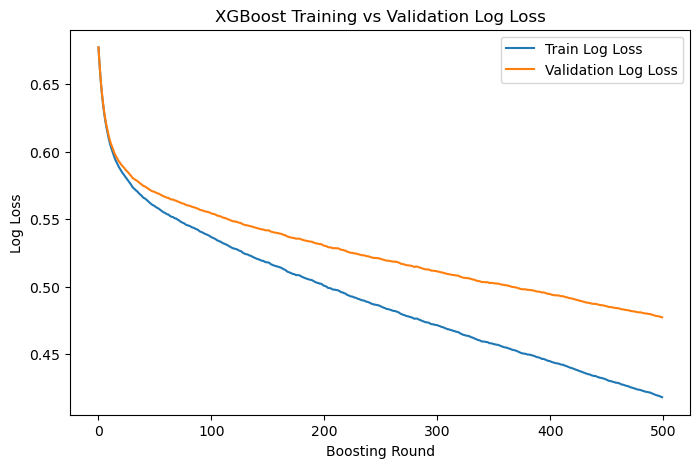

In [49]:
# Monitor convergence and overfitting


results = xgb_baseline.evals_result()

train_loss = results["validation_0"]["logloss"]
val_loss = results["validation_1"]["logloss"]

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Train Log Loss")
plt.plot(val_loss, label="Validation Log Loss")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Training vs Validation Log Loss")
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

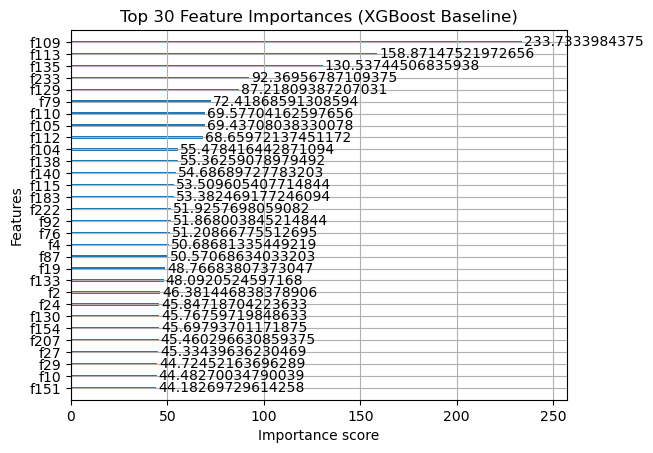

In [130]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_importance(
    xgb_baseline,
    max_num_features=30,  
    importance_type="gain"
)
plt.title("Top 30 Feature Importances (XGBoost Baseline)")
plt.show()

In [51]:
# Effect of learning rate

learning_rates = [0.01, 0.1, 0.3]
lr_results = []
lr_loss_curves = {}

for lr in learning_rates:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_estimators=500,
        learning_rate=lr,
        max_depth=6,
        subsample=0.8,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=30
    )
    
    model.fit(
        X_train_gbdt, y_train,
        eval_set=[(X_train_gbdt, y_train), (X_val_gbdt, y_val)],
        verbose=False
    )
    
    # predictions
    y_val_proba = model.predict_proba(X_val_gbdt)[:, 1]
    y_val_pred = (y_val_proba >= 0.5).astype(int)
    
    # save metrics
    lr_results.append({
        "learning_rate": lr,
        "best_iteration": model.best_iteration if hasattr(model, "best_iteration") else None,
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "val_precision": precision_score(y_val, y_val_pred, zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, zero_division=0),
        "val_auc": roc_auc_score(y_val, y_val_proba),
        "val_logloss": log_loss(y_val, y_val_proba)
    })
    
    # save loss curves
    results = model.evals_result()
    lr_loss_curves[lr] = {
        "train": results["validation_0"]["logloss"],
        "val": results["validation_1"]["logloss"]
    }

lr_results_df = pd.DataFrame(lr_results)
print(lr_results_df)

   learning_rate  best_iteration  val_accuracy  val_precision  val_recall  \
0           0.01             499      0.709693       0.168279    0.658432   
1           0.10             499      0.767598       0.184353    0.548604   
2           0.30             499      0.820691       0.198114    0.400644   

     val_f1   val_auc  val_logloss  
0  0.268051  0.753949     0.568152  
1  0.275969  0.744093     0.477303  
2  0.265127  0.712116     0.398478  


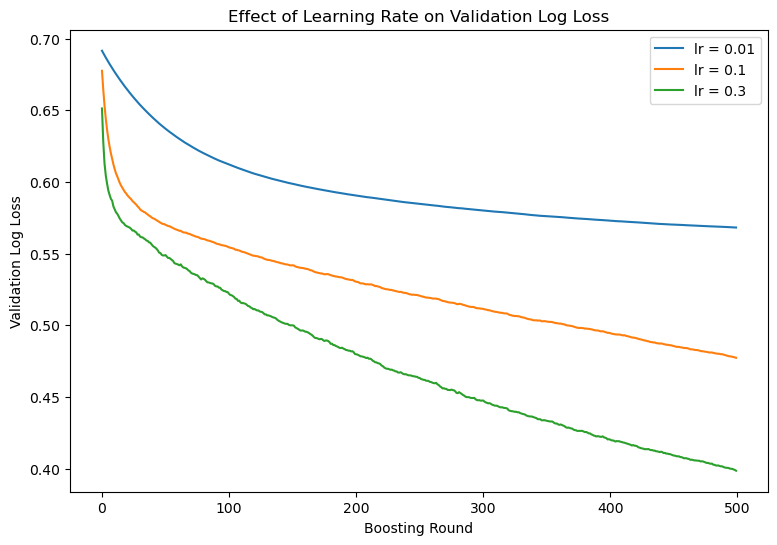

In [53]:
plt.figure(figsize=(9, 6))

for lr in learning_rates:
    plt.plot(
        lr_loss_curves[lr]["val"],
        label=f"lr = {lr}"
    )

plt.xlabel("Boosting Round")
plt.ylabel("Validation Log Loss")
plt.title("Effect of Learning Rate on Validation Log Loss")
plt.legend()
plt.show()

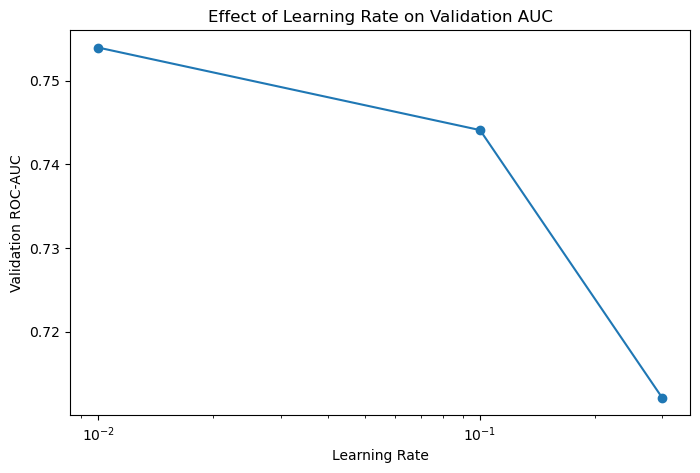

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(lr_results_df["learning_rate"], lr_results_df["val_auc"], marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Validation ROC-AUC")
plt.title("Effect of Learning Rate on Validation AUC")
plt.show()

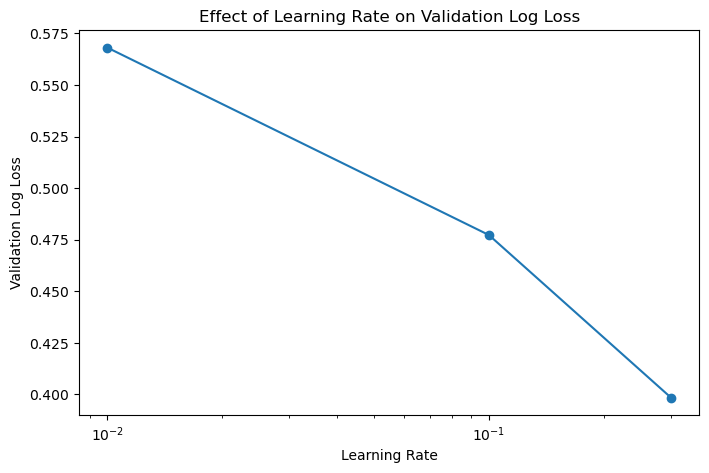

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(lr_results_df["learning_rate"], lr_results_df["val_logloss"], marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Log Loss")
plt.title("Effect of Learning Rate on Validation Log Loss")
plt.show()

In [59]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

In [61]:
def evaluate_binary_classifier(y_true, y_pred, y_pred_proba, dataset_name="Dataset"):
    print(f"\n{dataset_name} Metrics")
    print("-" * 30)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
    print("ROC-AUC  :", roc_auc_score(y_true, y_pred_proba))
    print("Log Loss :", log_loss(y_true, y_pred_proba))

In [63]:
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    learning_rate_init=0.001,
    max_iter=100,
    random_state=SEED
)

mlp_baseline.fit(X_train_mlp_dense, y_train)

/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [64]:
# Predicted probabilities
y_train_pred_proba_mlp = mlp_baseline.predict_proba(X_train_mlp_dense)[:, 1]
y_val_pred_proba_mlp = mlp_baseline.predict_proba(X_val_mlp_dense)[:, 1]
y_test_pred_proba_mlp = mlp_baseline.predict_proba(X_test_mlp_dense)[:, 1]

# Predicted labels
y_train_pred_mlp = (y_train_pred_proba_mlp >= 0.5).astype(int)
y_val_pred_mlp = (y_val_pred_proba_mlp >= 0.5).astype(int)
y_test_pred_mlp = (y_test_pred_proba_mlp >= 0.5).astype(int)

In [65]:
evaluate_binary_classifier(y_train, y_train_pred_mlp, y_train_pred_proba_mlp, "Train (MLP Baseline)")
evaluate_binary_classifier(y_val, y_val_pred_mlp, y_val_pred_proba_mlp, "Validation (MLP Baseline)")
evaluate_binary_classifier(y_test, y_test_pred_mlp, y_test_pred_proba_mlp, "Test (MLP Baseline)")


Train (MLP Baseline) Metrics
------------------------------
Accuracy : 0.9252474948549873
Precision: 0.6610721442885772
Recall   : 0.15186741094550268
F1-score : 0.24699330806308203
ROC-AUC  : 0.8441004834825137
Log Loss : 0.2123951847809517

Validation (MLP Baseline) Metrics
------------------------------
Accuracy : 0.9120254948294925
Precision: 0.3035294117647059
Recall   : 0.06928034371643395
F1-score : 0.11281154350677744
ROC-AUC  : 0.6942313439053278
Log Loss : 0.28096844185638864

Test (MLP Baseline) Metrics
------------------------------
Accuracy : 0.9113317579725541
Precision: 0.2896551724137931
Recall   : 0.06766917293233082
F1-score : 0.10970831519373095
ROC-AUC  : 0.7078109758208999
Log Loss : 0.2785573913343051


In [66]:
print("Number of training iterations:", mlp_baseline.n_iter_)
print("Final training loss:", mlp_baseline.loss_)

Number of training iterations: 100
Final training loss: 0.2171815814408171


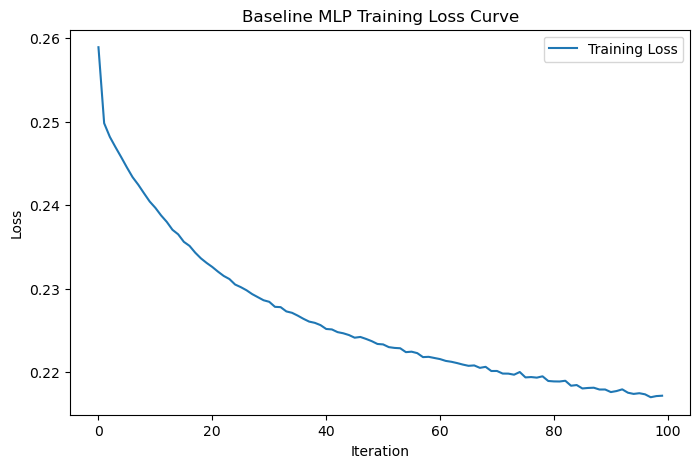

In [71]:
# Plot training loss curve
plt.figure(figsize=(8, 5))
plt.plot(mlp_baseline.loss_curve_, label="Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Baseline MLP Training Loss Curve")
plt.legend()
plt.show()

In [73]:
# Effect of hidden_layer_sizes

hidden_configs = [
    (64,),
    (128, 64),
    (256, 128, 64)
]

mlp_results = []

for config in hidden_configs:
    model = MLPClassifier(
        hidden_layer_sizes=config,
        activation="relu",
        learning_rate_init=0.001,
        max_iter=100,
        random_state=SEED
    )
    
    model.fit(X_train_mlp_dense, y_train)
    
    # predictions
    y_val_proba = model.predict_proba(X_val_mlp_dense)[:, 1]
    y_val_pred = (y_val_proba >= 0.5).astype(int)
    
    mlp_results.append({
        "hidden_layers": str(config),
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "val_precision": precision_score(y_val, y_val_pred, zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, zero_division=0),
        "val_auc": roc_auc_score(y_val, y_val_proba),
        "val_logloss": log_loss(y_val, y_val_proba)
    })

mlp_results_df = pd.DataFrame(mlp_results)
print(mlp_results_df)

/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


    hidden_layers  val_accuracy  val_precision  val_recall    val_f1  \
0           (64,)      0.912025       0.303529    0.069280  0.112812   
1       (128, 64)      0.879593       0.185783    0.145274  0.163050   
2  (256, 128, 64)      0.866065       0.162541    0.158700  0.160598   

    val_auc  val_logloss  
0  0.694231     0.280968  
1  0.616604     0.560762  
2  0.583794     1.347535  


/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


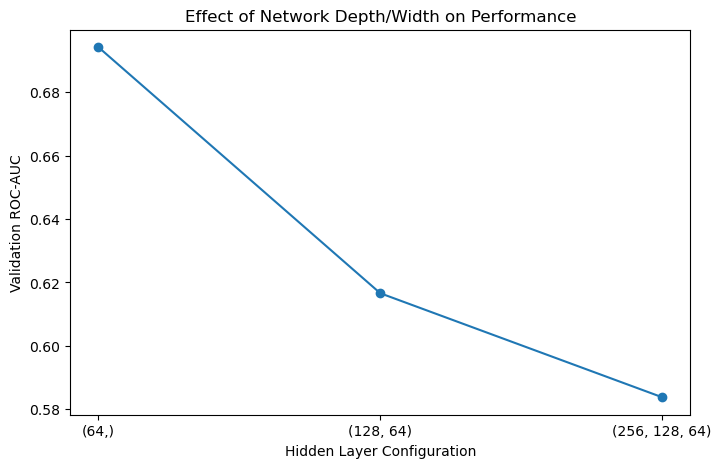

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_results_df["hidden_layers"], mlp_results_df["val_auc"], marker="o")
plt.xlabel("Hidden Layer Configuration")
plt.ylabel("Validation ROC-AUC")
plt.title("Effect of Network Depth/Width on Performance")
plt.show()

In [77]:
# Effect of activation


activations = ["relu", "tanh"]
activation_results = []

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(64,),
        activation=act,
        learning_rate_init=0.001,
        max_iter=100,
        random_state=SEED
    )
    
    model.fit(X_train_mlp_dense, y_train)
    
    # predictions
    y_val_proba = model.predict_proba(X_val_mlp_dense)[:, 1]
    y_val_pred = (y_val_proba >= 0.5).astype(int)
    
    activation_results.append({
        "activation": act,
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "val_precision": precision_score(y_val, y_val_pred, zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, zero_division=0),
        "val_auc": roc_auc_score(y_val, y_val_proba),
        "val_logloss": log_loss(y_val, y_val_proba)
    })

activation_results_df = pd.DataFrame(activation_results)
print(activation_results_df)

/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


  activation  val_accuracy  val_precision  val_recall    val_f1   val_auc  \
0       relu      0.912025       0.303529    0.069280  0.112812  0.694231   
1       tanh      0.908340       0.262712    0.074919  0.116590  0.680656   

   val_logloss  
0     0.280968  
1     0.295733  


/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


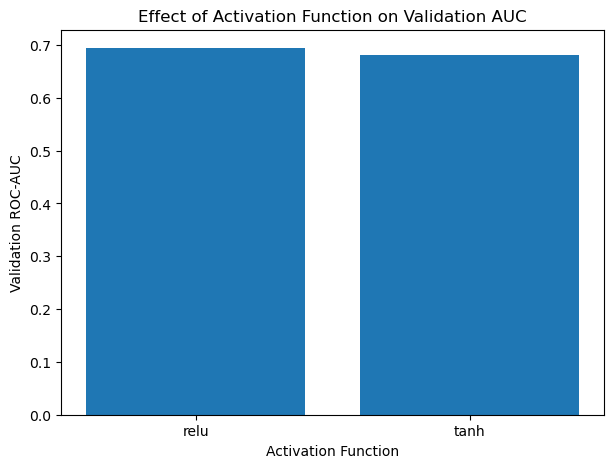

In [78]:
plt.figure(figsize=(7, 5))
plt.bar(activation_results_df["activation"], activation_results_df["val_auc"])
plt.xlabel("Activation Function")
plt.ylabel("Validation ROC-AUC")
plt.title("Effect of Activation Function on Validation AUC")
plt.show()

In [81]:
# Effect of learning_rate_init

learning_rates = [0.001, 0.01, 0.1]
lr_results = []

for lr in learning_rates:
    model = MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        learning_rate_init=lr,
        max_iter=100,
        random_state=SEED
    )
    
    model.fit(X_train_mlp_dense, y_train)
    
    y_val_proba = model.predict_proba(X_val_mlp_dense)[:, 1]
    y_val_pred = (y_val_proba >= 0.5).astype(int)
    
    lr_results.append({
        "learning_rate": lr,
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "val_precision": precision_score(y_val, y_val_pred, zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, zero_division=0),
        "val_auc": roc_auc_score(y_val, y_val_proba),
        "val_logloss": log_loss(y_val, y_val_proba)
    })

lr_results_df = pd.DataFrame(lr_results)
print(lr_results_df)

/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


   learning_rate  val_accuracy  val_precision  val_recall    val_f1   val_auc  \
0          0.001      0.912025       0.303529    0.069280  0.112812  0.694231   
1          0.010      0.916036       0.136585    0.007519  0.014253  0.729293   
2          0.100      0.918421       0.102041    0.001343  0.002650  0.705920   

   val_logloss  
0     0.280968  
1     0.275992  
2     0.289045  


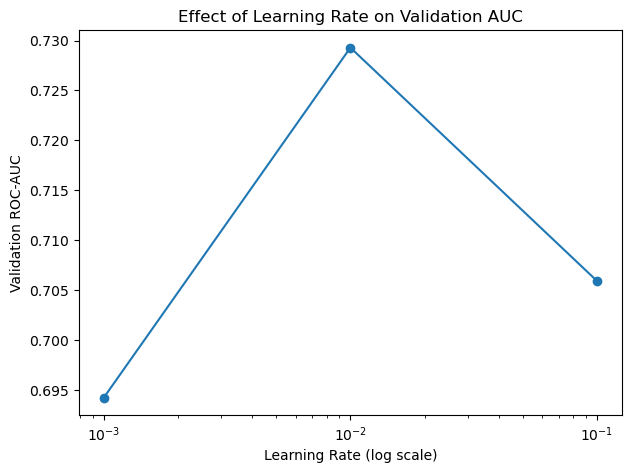

In [83]:
plt.figure(figsize=(7, 5))
plt.plot(lr_results_df["learning_rate"], lr_results_df["val_auc"], marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Validation ROC-AUC")
plt.title("Effect of Learning Rate on Validation AUC")
plt.show()

In [114]:
final_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_estimators=500,
    learning_rate=0.3,  
    max_depth=6,
    subsample=0.8,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False
)

final_xgb.fit(X_train_gbdt, y_train, verbose=False)

/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [00:21:06] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1770963443521/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [115]:
final_mlp = MLPClassifier(
    hidden_layer_sizes=(64,),   # best hidden layer setting
    activation="relu",          # best activation
    learning_rate_init=0.01,    # best learning rate
    max_iter=100,
    random_state=SEED
)

final_mlp.fit(X_train_mlp_dense, y_train)

/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [116]:
# GBDT predictions
xgb_test_proba = final_xgb.predict_proba(X_test_gbdt)[:, 1]
xgb_test_pred = (xgb_test_proba >= 0.5).astype(int)

# MLP predictions
mlp_test_proba = final_mlp.predict_proba(X_test_mlp_dense)[:, 1]
mlp_test_pred = (mlp_test_proba >= 0.5).astype(int)

In [117]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    average_precision_score
)

In [118]:
comparison_df = pd.DataFrame([
    {
        "Model": "GBDT (XGBoost)",
        "Accuracy": accuracy_score(y_test, xgb_test_pred),
        "Precision": precision_score(y_test, xgb_test_pred, zero_division=0),
        "Recall": recall_score(y_test, xgb_test_pred, zero_division=0),
        "F1-score": f1_score(y_test, xgb_test_pred, zero_division=0),
        "AUC-PR": average_precision_score(y_test, xgb_test_proba)
    },
    {
        "Model": "MLP",
        "Accuracy": accuracy_score(y_test, mlp_test_pred),
        "Precision": precision_score(y_test, mlp_test_pred, zero_division=0),
        "Recall": recall_score(y_test, mlp_test_pred, zero_division=0),
        "F1-score": f1_score(y_test, mlp_test_pred, zero_division=0),
        "AUC-PR": average_precision_score(y_test, mlp_test_proba)
    }
])

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,AUC-PR
0,GBDT (XGBoost),0.820517,0.199736,0.406821,0.267928,0.198036
1,MLP,0.916860,0.196721,0.009667,0.018428,0.204691


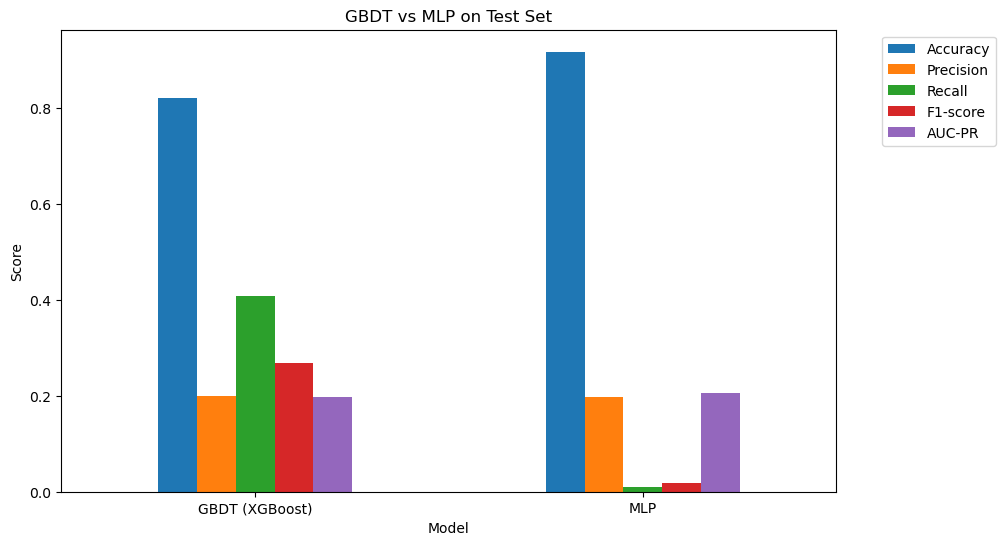

In [119]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "AUC-PR"]

comparison_plot_df = comparison_df.set_index("Model")[metrics_to_plot]

comparison_plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("GBDT vs MLP on Test Set")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [121]:
import time

In [122]:
# Time GBDT
start = time.time()
xgb_timed = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False
)
xgb_timed.fit(X_train_gbdt, y_train, verbose=False)
xgb_train_time = time.time() - start

# Time MLP
start = time.time()
mlp_timed = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=100,
    random_state=SEED
)
mlp_timed.fit(X_train_mlp_dense, y_train)
mlp_train_time = time.time() - start

time_df = pd.DataFrame([
    {"Model": "GBDT (XGBoost)", "Training Time (seconds)": xgb_train_time},
    {"Model": "MLP", "Training Time (seconds)": mlp_train_time}
])

time_df

/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [00:22:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1770963443521/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/geri/anaconda3/envs/btc311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Training Time (seconds)
0,GBDT (XGBoost),7.015282
1,MLP,54.094984
